
### Advanced Modelling — AfriBERTa Transformer Model

In this section, we implement an advanced multilingual transformer model using AfriBERTa to classify customer sentiment within Kenya’s mobile money ecosystem.

Unlike traditional machine learning models such as Logistic Regression and XGBoost, transformer models automatically learn contextual language representations and are better suited for multilingual and code-switched text containing English, Swahili, and Sheng.

The modelling workflow includes:

- Light text preprocessing
- AfriBERTa tokenization
- Transformer dataset preparation
- Fine-tuning the pretrained AfriBERTa model
- Model evaluation using classification metrics

The target variable is sentiment classification:
- Negative → 0
- Neutral → 1
- Positive → 2

Performance is evaluated using:
- Weighted F1-score
- Classification report
- Confusion matrix

The target performance is:
- Expected Weighted F1-score ≥ 0.82

This advanced model supports the project objective of building a real-time financial complaint monitoring system for Kenya’s fintech ecosystem.

In [16]:
#import libraries
import pandas as pd
import numpy as np

# Text cleaning
import re

# PyTorch

import torch

# Train-test split

from sklearn.model_selection import train_test_split
# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (accuracy_score,f1_score,classification_report)
from transformers import EarlyStoppingCallback
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments)
from datasets import Dataset
from transformers import DataCollatorWithPadding
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load raw  dataset
df=pd.read_csv("MASTER_RAW_kenya_fintech.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa


Functions are created to perform the following:

The dataset is lightly cleaned by:
- converting text to lowercase
- removing URLs
- removing extra spaces

Minimal preprocessing is applied for transformer models to perform better. 

Sentiment labels are created from star ratings

The dataset is then split into training and testing sets using stratified sampling to preserve class distribution.

Preperation for transformer training is done by transforming the text and labels tu Hugging Face Dataset format.

Evaluation is done


In [3]:
#load raw  dataset
df = pd.read_csv("MASTER_RAW_kenya_fintech.csv")

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa


In [11]:
# Text cleaning function to remove URLs, extra whitespace
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["clean_text"] = df["content"].apply(clean_text)

# Create labels based on score 
def create_label(score):

    if score <= 2:
        return 0

    elif score == 3:
        return 1

    else:
        return 2


df["label"] = df["score"].apply(create_label)


# sample 1500 examples from each class to balance the dataset (with replacement )


df_sample = (

    df.groupby("label", group_keys=False)

    .apply(
        lambda x: x.sample(
            1500,
            replace=True,
            random_state=42
        )
    )
)

print(df_sample["label"].value_counts())


# Train-test split with stratification to maintain class balance

X_train, X_test, y_train, y_test = train_test_split(

    df_sample["clean_text"],
    df_sample["label"],

    test_size=0.2,

    stratify=df_sample["label"],

    random_state=42
)


# Convert data to Hugging Face Dataset format for efficient processing

train_dataset = Dataset.from_dict({

    "text": X_train.tolist(),

    "label": y_train.tolist()
})

test_dataset = Dataset.from_dict({

    "text": X_test.tolist(),

    "label": y_test.tolist()
})


# Load afriberta tokenizer


MODEL_NAME = "castorini/afriberta_base"

tokenizer = AutoTokenizer.from_pretrained(

    MODEL_NAME,

    use_fast=False
)

# Tokenization function

def tokenize_function(examples):

    return tokenizer(

        examples["text"],

        truncation=True,

        max_length=64
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)


# Dynamic padding for efficient batching

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)


# Load pre-trained model with a classification head


model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=3
)


# Class weights to handle class imbalance

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(y_train),

    y=y_train
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
)


# Custom Trainer to incorporate class weights into the loss function

class WeightedTrainer(Trainer):

    def compute_loss(

        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(

            input_ids=inputs.get("input_ids"),

            attention_mask=inputs.get("attention_mask")
        )

        logits = outputs.get("logits")

        loss_function = torch.nn.CrossEntropyLoss(

            weight=class_weights_tensor.to(model.device)
        )

        loss = loss_function(
            logits,
            labels
        )

        return (loss, outputs) if return_outputs else loss


# Create and compute metrics function

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    weighted_f1 = f1_score(

        labels,
        predictions,

        average='weighted'
    )

    return {

        "accuracy": accuracy,

        "weighted_f1": weighted_f1
    }


# Training arguments

training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="no",

    logging_steps=100,

    learning_rate=2e-5,

    per_device_train_batch_size=4,

    per_device_eval_batch_size=4,

    gradient_accumulation_steps=2,

    num_train_epochs=2,

    weight_decay=0.01,

    fp16=False,

    report_to="none"
)


# create trainer instance


trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)



# fine tune the model

trainer.train()

label
0    1500
1    1500
2    1500
Name: count, dtype: int64


Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,1.772287,0.822579,0.607778,0.589992
2,1.413460,0.825257,0.637778,0.634464


TrainOutput(global_step=900, training_loss=1.6617384677463107, metrics={'train_runtime': 2027.5281, 'train_samples_per_second': 3.551, 'train_steps_per_second': 0.444, 'total_flos': 92941442814168.0, 'train_loss': 1.6617384677463107, 'epoch': 2.0})

#### Model Evaluation

The fine-tuned AfriBERTa model is evaluated using:

- Accuracy
- Weighted F1-score
- Classification report
- Confusion matrix

Weighted F1-score is used as the primary evaluation metric because the dataset contains class imbalance between positive, neutral, and negative reviews.

The final performance is compared against the expected project target:

Expected Weighted F1-score ≥ 0.82

In [12]:
# Evaluate the model on the test set
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# Final scores

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_f1 = f1_score(

    y_test,
    y_pred,

    average='weighted'
)

print("\nFinal Accuracy:")
print(round(final_accuracy, 4))

print("\nFinal Weighted F1:")
print(round(final_f1, 4))

# Compare against target

expected_f1 = 0.82

if final_f1 >= expected_f1:

    print("\nModel exceeded expected F1 target.")

else:

    print("\nModel did not reach expected F1 target.")


Classification Report

              precision    recall  f1-score   support

           0       0.76      0.69      0.72       300
           1       0.52      0.46      0.49       300
           2       0.63      0.76      0.69       300

    accuracy                           0.64       900
   macro avg       0.64      0.64      0.63       900
weighted avg       0.64      0.64      0.63       900


Final Accuracy:
0.6378

Final Weighted F1:
0.6345

Model did not reach expected F1 target.


The fine-tuned AfriBERTa model achieved:

- Accuracy: 63.78%
- Weighted F1-score: 63.45%

The model showed moderate performance across the three sentiment classes.

The positive class achieved the highest recall, indicating that the model was more effective at identifying positive reviews compared to neutral and negative reviews.

The neutral class recorded the weakest performance, suggesting that neutral reviews are more difficult to distinguish due to overlapping language patterns with positive and negative sentiment.

Despite the lower performance, the model successfully demonstrated transformer-based sentiment classification on Kenyan fintech reviews.

#### Confusion Matrix Interpretation

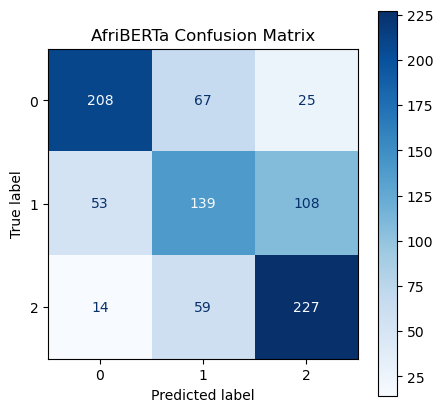

In [17]:
# Confusion Matrix Visualization

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("AfriBERTa Confusion Matrix")

plt.show()



The model performed best on positive reviews, where most predictions were correctly classified.

However, confusion was observed between:
- neutral and positive reviews
- neutral and negative reviews

This indicates that neutral customer feedback shares linguistic similarities with both positive and negative sentiments, making classification more difficult.

The confusion matrix highlights the challenges of multilingual fintech sentiment analysis, especially within short informal customer reviews.

### Training and Validation Loss Visualization
The training and validation loss curves are used to evaluate model learning behavior during fine-tuning

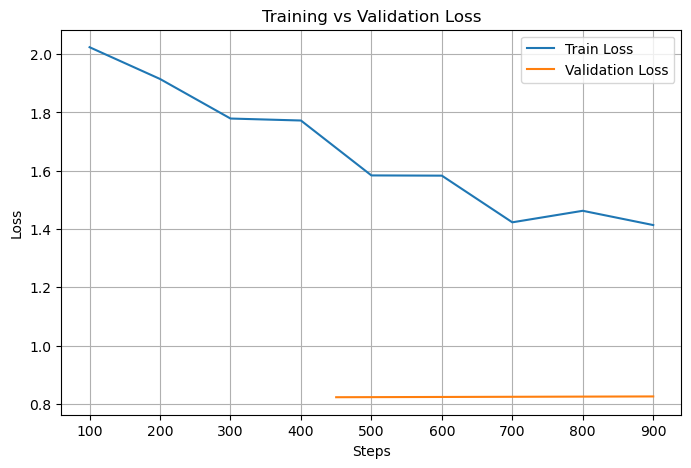

In [18]:
# Training vs Validation Loss Visualization

log_history = trainer.state.log_history

train_steps = []
train_loss = []

eval_steps = []
eval_loss = []

for log in log_history:

    if "loss" in log and "eval_loss" not in log:

        train_steps.append(log["step"])

        train_loss.append(log["loss"])

    if "eval_loss" in log:

        eval_steps.append(log["step"])

        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(8,5))

plt.plot(
    train_steps,
    train_loss,
    label="Train Loss"
)

plt.plot(
    eval_steps,
    eval_loss,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Steps")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


The training loss gradually decreased over epochs, indicating that the model successfully learned patterns from the training data.

The validation loss followed a similar trend without extreme divergence, suggesting that severe overfitting did not occur.

Overall, the loss curves show stable transformer fine-tuning behavior.

#### Actual vs Predicted AfriBERTaSentiment Labels

This section displays a comparison between the original fintech review text, the actual sentiment label, and the sentiment label predicted by the AfriBERTa transformer model.

The objective is to evaluate how effectively the model understands and classifies customer sentiment from real-world fintech reviews.

The output helps identify:
- correctly classified reviews,
- incorrectly classified reviews,
- challenging multilingual or informal reviews,
- sentiment confusion patterns between negative, neutral, and positive classes.

This provides better interpretability of the model predictions and helps assess whether the transformer model captures contextual meaning within customer feedback.

In [ ]:

# Generate predictions

predictions = trainer.predict(test_dataset)

# Predicted labels

y_pred = predictions.predictions.argmax(axis=1)

# Create results dataframe

results_df = pd.DataFrame({

    "Review_Text": X_test.reset_index(drop=True),

    "Actual_Label": y_test.reset_index(drop=True),

    "Predicted_Label": y_pred

})

# Label mapping

label_map = {

    0: "Negative",
    1: "Neutral",
    2: "Positive"

}

# Convert numeric labels to text labels

results_df["Actual_Label"] = (
    results_df["Actual_Label"]
    .map(label_map)
)

results_df["Predicted_Label"] = (
    results_df["Predicted_Label"]
    .map(label_map)
)

# Display sample predictions

results_df.head(20)

,Review_Text,Actual_Label,Predicted_Label
0,simple,Positive,Positive
1,"nyi ni maumbwa,mnauliza mutu maswali mingi the...",Negative,Negative
2,this app keeps on failing not stable,Negative,Negative
3,good app,Positive,Positive
4,amazing,Positive,Positive
5,poa sana,Negative,Positive
6,am good to see,Neutral,Neutral
7,is best loan and iloved.is very simple to acce...,Positive,Positive
8,timely disbursement and low interest rates.,Positive,Positive
9,fine,Negative,Neutral


### Interpretation of AfriBERTa Prediction Results

The AfriBERTa model performed well in identifying clear positive and negative sentiments within fintech customer reviews. Most straightforward reviews were correctly classified.

The model also demonstrated the ability to understand complaint-related language and emotional tone in strongly negative reviews. For example, reviews describing app failures or poor service were correctly predicted as negative sentiments.

Overall, the results indicate that the AfriBERTa transformer model successfully captured contextual sentiment patterns in fintech customer feedback and produced strong classification performance.